Loading SCRFD model...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: 

Saving group of people.avif to group of people.avif
Image uploaded: group of people.avif

Running face detection...
Total faces detected: 7

Face 1:
  Bounding box : [148 140 173 184]
  Confidence   : 0.8539000153541565
  Landmarks    : [[154 156]
 [167 156]
 [161 165]
 [155 172]
 [167 172]]

Face 2:
  Bounding box : [459 131 486 179]
  Confidence   : 0.8532000184059143
  Landmarks    : [[466 148]
 [479 150]
 [471 159]
 [465 164]
 [477 166]]

Face 3:
  Bounding box : [372 153 399 198]
  Confidence   : 0.842199981212616
  Landmarks    : [[379 171]
 [392 169]
 [387 180]
 [382 187]
 [393 186]]

Face 4:
  Bounding box : [301 122 328 174]
  Confidence   : 0.8159000277519226
  Landmarks    : [[307 141]
 [321 142]
 [313 152]
 [306 158]
 [320 159]]

Face 5:
  Bounding box : [ 68 133  95 179]
  Confidence   : 0.8151000142097473
  Landmarks    : [[ 76 148]
 [ 89 147]
 [ 84 158]
 [ 77 166]
 [ 89 165]]

Face 6:
  Bounding box : [217 179 242 224]
  Confidence   : 0.7972000241279602
  Landmarks    :

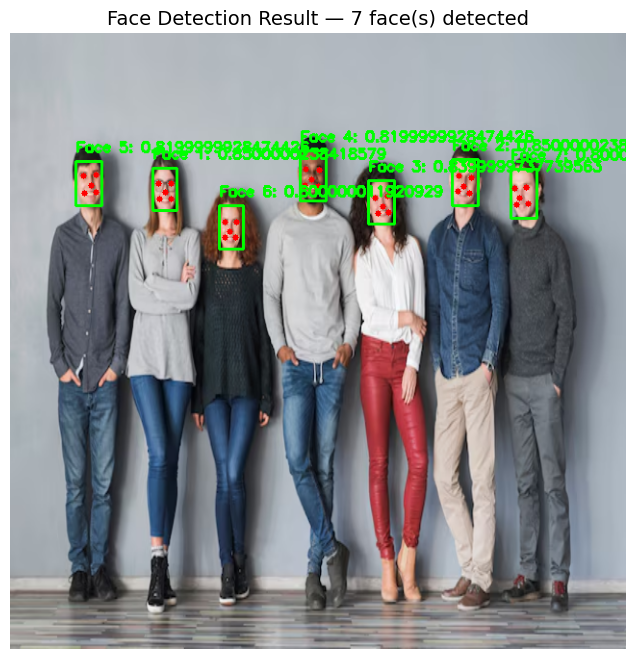

In [14]:
# ============================================================
# Face Detection using SCRFD
# ============================================================
# Description  : Upload any image → detect all faces
#                using pretrained SCRFD model
# Model        : SCRFD via InsightFace (buffalo_l)
# Author       : Fatima
# ============================================================

# ── Step 1: Install Required Libraries ──────────────────────
!pip install insightface onnxruntime -q

# ── Step 2: Import Required Libraries ───────────────────────
import cv2                               # image processing
import numpy as np                       # numerical operations
import matplotlib.pyplot as plt          # displaying images
from insightface.app import FaceAnalysis # pretrained SCRFD model
from google.colab import files           # file upload in Colab

# ── Step 3: Load Pretrained SCRFD Model ─────────────────────
# buffalo_l = most accurate pretrained model in InsightFace
# trained on millions of faces → ready to use immediately
print("Loading SCRFD model...")
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))
print("SCRFD model ready!")

# ── Step 4: Ask User to Upload Image ────────────────────────
# files.upload() opens a file picker in Google Colab
# user can upload any image from their computer
print("\nPlease upload an image...")
uploaded = files.upload()

# get uploaded filename automatically
filename = list(uploaded.keys())[0]
print(f"Image uploaded: {filename}")

# ── Step 5: Read and Prepare Image ──────────────────────────
# read uploaded image from disk
img = cv2.imread(filename)

# resize to 640x640 for better SCRFD detection
# SCRFD works best with larger images
img_resized = cv2.resize(img, (640, 640))

# ── Step 6: Run SCRFD Face Detection ────────────────────────
print("\nRunning face detection...")
faces = app.get(img_resized)
print(f"Total faces detected: {len(faces)}")

# print details for each detected face
for i, face in enumerate(faces):
    print(f"\nFace {i+1}:")
    print(f"  Bounding box : {face.bbox.astype(int)}")
    print(f"  Confidence   : {round(face.det_score, 4)}")
    print(f"  Landmarks    : {face.kps.astype(int)}")

# ── Step 7: Draw Bounding Boxes and Landmarks ───────────────
# make copy of image so original is not modified
img_result = img_resized.copy()

for i, face in enumerate(faces):
    # get bounding box coordinates as integers
    x1, y1, x2, y2 = face.bbox.astype(int)

    # draw green rectangle around detected face
    # (0, 255, 0) = green color, 2 = line thickness
    cv2.rectangle(img_result, (x1, y1), (x2, y2),
                  (0, 255, 0), 2)

    # write face number and confidence score above box
    score_text = f"Face {i+1}: {round(face.det_score, 2)}"
    cv2.putText(img_result, score_text, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                (0, 255, 0), 2)

    # draw 5 facial landmarks as red dots
    # landmarks = eyes, nose, mouth corners
    for point in face.kps.astype(int):
        cv2.circle(img_result, tuple(point),
                   3, (0, 0, 255), -1)

# ── Step 8: Display Final Result ────────────────────────────
# convert BGR (OpenCV format) to RGB (matplotlib format)
img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

# display image with detection results
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"Face Detection Result — {len(faces)} face(s) detected",
          fontsize=14)
plt.axis('off')
plt.show()